# Degradados

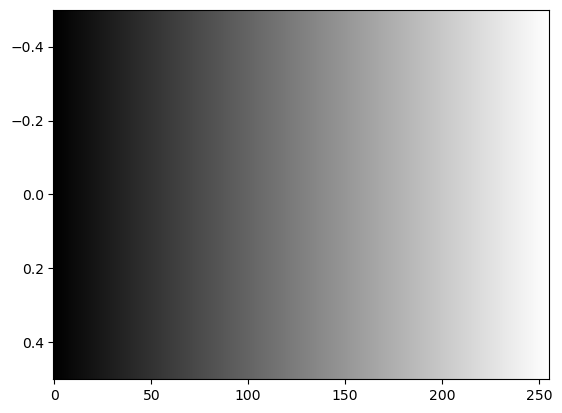

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Definicion de colores
colores = [(0, 'black'), (1, 'white')] # Para generar escala de grises
cmap = LinearSegmentedColormap.from_list('degradado', colores) # Generamos el colormap a traves de nuestro array de colores
imagen_degradado = cmap(np.linspace(0, 1, 256)) # Generamos la imagen de degradado

plt.imshow([imagen_degradado], aspect='auto')
plt.show()

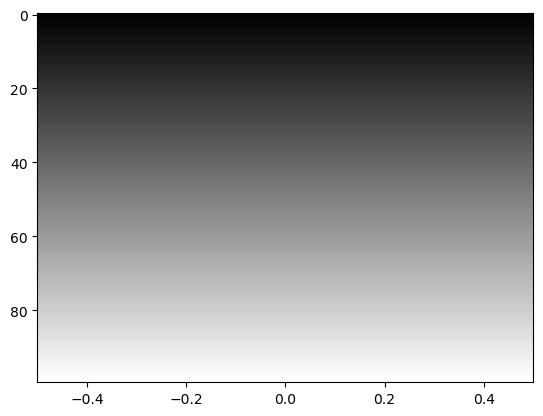

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Definicion de colores
colores = [(0, 'black'), (1, 'white')] # Para generar escala de grises
cmap = LinearSegmentedColormap.from_list('degradado', colores) # Generamos el colormap a traves de nuestro array de colores
imagen_degradado = cmap(np.linspace(0, 1, 100).reshape(-1, 1)) # Generamos la imagen de degradado

plt.imshow(imagen_degradado, aspect='auto')
plt.show()

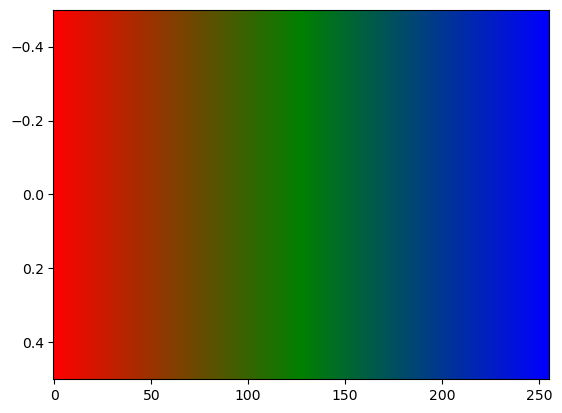

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Definicion de colores
colores = [(0, 'red'), (0.5, 'green'), (1, 'blue')] # Para generar escala de colores
cmap = LinearSegmentedColormap.from_list('degradado', colores) # Generamos el colormap a traves de nuestro array de colores
imagen_degradado = cmap(np.linspace(0, 1, 256)) # Generamos la imagen de degradado

plt.imshow([imagen_degradado], aspect='auto')
plt.show()

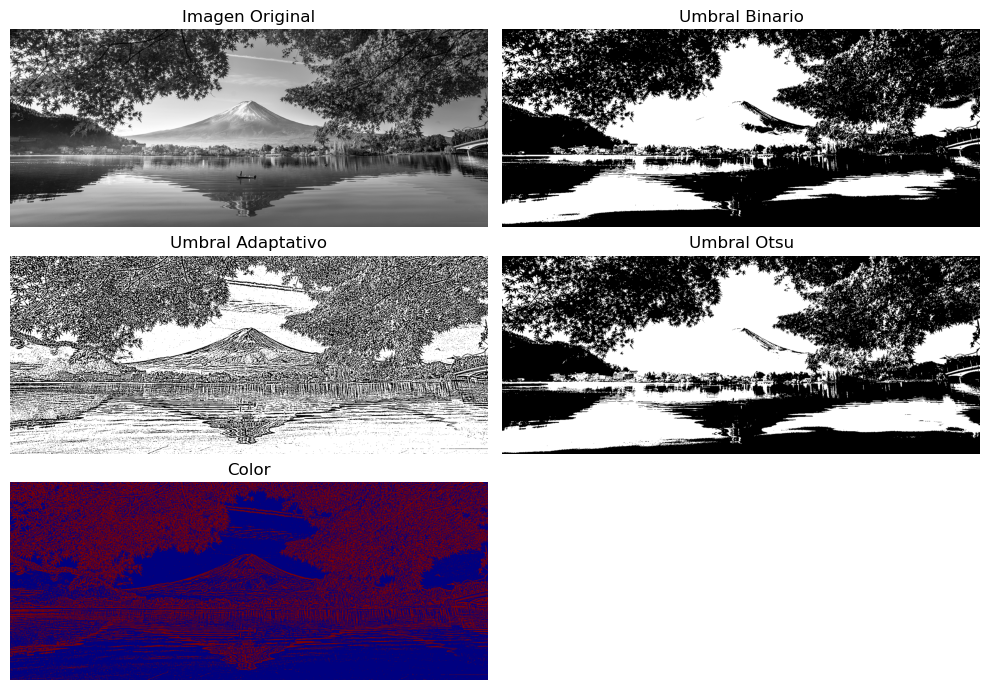

In [7]:
import cv2
import matplotlib.pyplot as plt

imagen = cv2.imread('./images/1.jpeg', 0) # Leemos la imagen en escala de grises

_, umbra_binaria = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY) # Aplicamos el umbral binario
umbra_adaptativa = cv2.adaptiveThreshold(imagen, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2) # Aplicamos el umbral adaptativo
_, umbra_otsu = cv2.threshold(imagen, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU) # Aplicamos el umbral de Otsu

color = cv2.applyColorMap(umbra_adaptativa, cv2.COLORMAP_JET) # Aplicamos un mapa de color a la imagen original

plt.figure(figsize=(10, 7))

plt.subplot(3, 2, 1)
plt.imshow(imagen, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(3, 2, 2)
plt.imshow(umbra_binaria, cmap='gray')
plt.title('Umbral Binario')
plt.axis('off')

plt.subplot(3, 2, 3)
plt.imshow(umbra_adaptativa, cmap='gray')
plt.title('Umbral Adaptativo')
plt.axis('off')

plt.subplot(3, 2, 4)
plt.imshow(umbra_otsu, cmap='gray')
plt.title('Umbral Otsu')
plt.axis('off')

plt.subplot(3, 2, 5)
plt.imshow(color)
plt.title('Color')
plt.axis('off')

plt.tight_layout()
plt.show()


# Mascaras

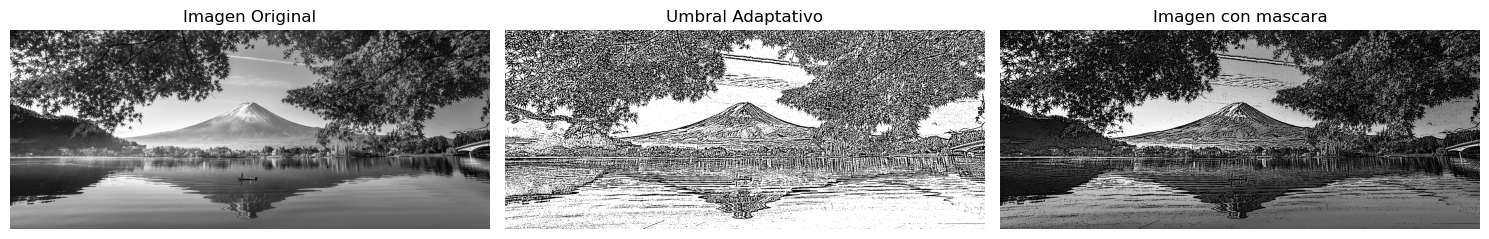

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('./images/1.jpeg', 0) # Leemos la imagen en escala de grises

umbra_adaptativa = cv2.adaptiveThreshold(imagen, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2) # Aplicamos el umbral adaptativo

mask = umbra_adaptativa == 255
img_junta = cv2.bitwise_and(imagen, imagen, mask=umbra_adaptativa) # Aplicamos la mascara a la imagen original

plt.figure(figsize=(15, 7))

plt.subplot(1, 3, 1)
plt.imshow(imagen, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(umbra_adaptativa, cmap='gray')
plt.title('Umbral Adaptativo')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_junta, cmap='gray')
plt.title('Imagen con mascara')
plt.axis('off')

plt.tight_layout()
plt.show()



# Solarizacion y negativo

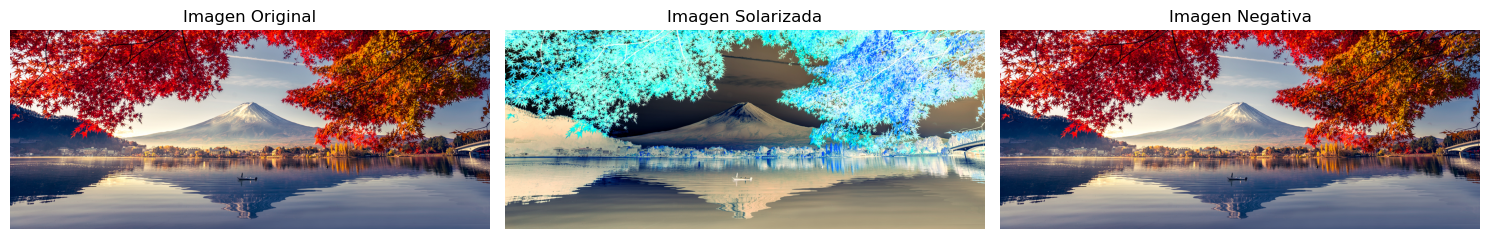

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('./images/1.jpeg')

def solarizar(imagen, umbral):
  img_solarizada = np.where(imagen < umbral, imagen, 255 - imagen) # Aplicamos la solarizacion
  return img_solarizada

imagen_solarizada = solarizar(imagen, 0)
imagen_negativo = 255 - imagen_solarizada

plt.figure(figsize=(15, 7))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(imagen_solarizada, cv2.COLOR_BGR2RGB))
plt.title('Imagen Solarizada')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(imagen_negativo, cv2.COLOR_BGR2RGB))
plt.title('Imagen Negativa')
plt.axis('off')

plt.tight_layout()
plt.show()